salePrice is my target variable and want to predict it.
The data have 1460 rows and 81 columns.
Dataset contains numerical , categorical and ordinal features.
Data have misiing values,9pool,garage,basement features have 
the maximum missing values. 

In [1]:
import os

In [4]:
os.getcwd()

In [3]:
import numpy as np
import pandas as pd
data = pd.read_csv('../data/raw/train.csv')
print("rows,columns",data.shape)
print(data.columns)

Identifying the featurestype in dataset.

In [13]:
#for col,dtypes in data.dtypes.items():
 #   print(col,'-',dtypes)
pd.set_option('display.max_rows',None)
data.dtypes

In [5]:
pd.set_option('display.max_columns',None)
data.describe(include='all')

Identifying null values in dataset.

In [ ]:
data.info()

Identifying columns which have null(missing) values.

In [6]:
pd.set_option('display.max_rows',None)
missing = data.columns[data.isnull().any()]
print(missing)


In [ ]:
#pd.set_option('display.max_rows',None) 
for col in missing:
    
    print(data[col].isnull().value_counts())
    print('\n')


In [9]:
data['BsmtQual'].unique()


array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In this step we identyfies the outliers in different features

<Axes: xlabel='LotFrontage'>

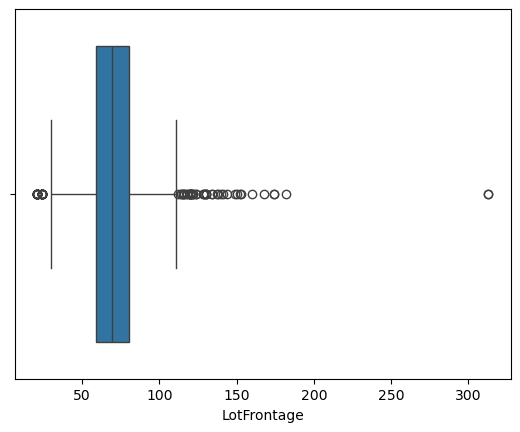

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=data['LotFrontage'])
plt.show()


Here we found multiple features with null(missing) values , all features are differentiated with their types.

| Feature Name | Data Type   | Category Type    | Missing Value Type |
| ------------ | ----------- | ---------------- | ------------------ |
| BsmtQual     | Categorical | Ordinal          | Structural         |
| BsmtCond     | Categorical | Ordinal          | Structural         |
| BsmtExposure | Categorical | Ordinal          | Structural         |
| BsmtFinType1 | Categorical | Ordinal          | Structural         |
| BsmtFinType2 | Categorical | Ordinal          | Structural         |
| FireplaceQu  | Categorical | Ordinal          | Structural         |
| GarageQual   | Categorical | Ordinal          | Structural         |
| GarageCond   | Categorical | Ordinal          | Structural         |
| PoolQC       | Categorical | Ordinal          | Structural         |
| Fence        | Categorical | Ordinal          | Structural         |
| GarageType   | Categorical | Nominal          | Structural         |
| GarageFinish | Categorical | Nominal          | Structural         |
| MiscFeature  | Categorical | Nominal          | Structural         |
| Alley        | Categorical | Nominal          | Structural         |
| MasVnrType   | Categorical | Nominal          | Structural         |
| MasVnrArea   | Numerical   | With Outliers    | Structural         |
| GarageYrBlt  | Numerical   | Without Outliers | Structural         |
| Electrical   | Categorical | Nominal          | **Accidental**     |
| LotFrontage  | Numerical   | With Outliers    | **Accidental**     |

In [11]:
#find which are nullvalues NA or Nan 
print(data['BsmtQual'].isna().sum())
print((data['BsmtQual'] == 'NA').sum())

37
0


In [ ]:
data.info()


In [16]:
data['FireplaceQu'].isna().sum()

690

In [18]:
data['PoolQC'].isna().sum()

1453

In [20]:
data['Fence'].isna().sum()

1179

In [22]:
data['MiscFeature'].isna().sum()

1406

In [24]:
data['MasVnrType'].isna().sum()

872

In [26]:
data['MasVnrArea'].isna().sum()

8

In [28]:
data['Alley'].isna().sum()

1369

In [30]:
data['Electrical'].isna().sum()

1

In [33]:
data['LotFrontage'].isna().sum()

259

In [11]:
data.info()
data.head(50)

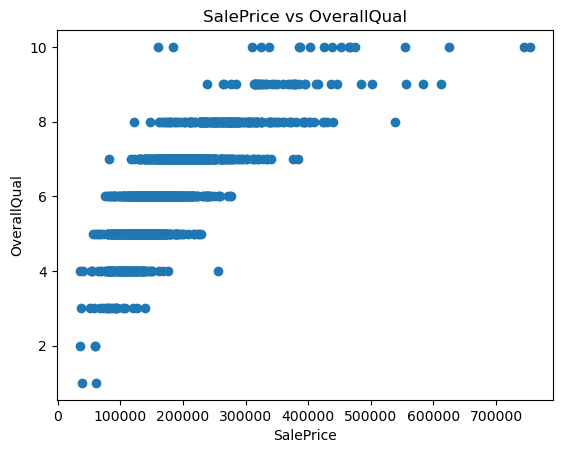

In [38]:
import matplotlib.pyplot as plt
x= data['SalePrice']
y= data['OverallQual']
plt.scatter(x,y)
plt.xlabel('SalePrice')
plt.ylabel('OverallQual')
plt.title('SalePrice vs OverallQual')
plt.show()

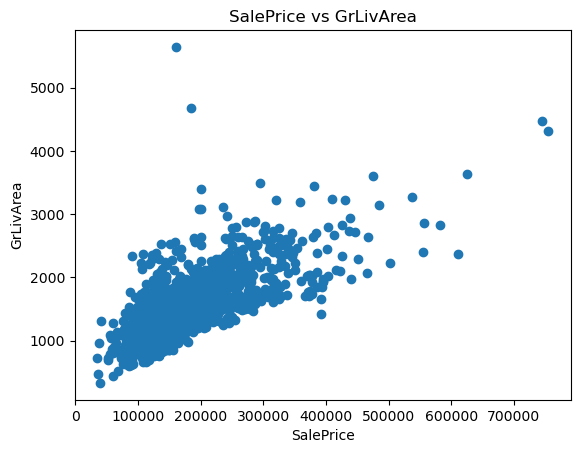

In [39]:
x= data['SalePrice']
y= data['GrLivArea']
plt.scatter(x,y)
plt.xlabel('SalePrice')
plt.ylabel('GrLivArea')
plt.title('SalePrice vs GrLivArea')
plt.show()

Lets handle categorical features.first start with ordinal categorical featues

In [40]:
ordinal_features = [
    'LotShape',
    'Utilities',
    'LandSlope',
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PavedDrive',
    'PoolQC',
    'Fence'
]

In [41]:
ordinal_categories = [
    ['Reg', 'IR1', 'IR2', 'IR3'],                       # LotShape
    ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],               # Utilities
    ['Sev', 'Mod', 'Gtl'],                              # LandSlope
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # ExterQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # ExterCond
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # BsmtQual
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # BsmtCond
    ['NA', 'No', 'Mn', 'Av', 'Gd'],                     # BsmtExposure
    ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],   # BsmtFinType1
    ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],   # BsmtFinType2
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # HeatingQC
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # KitchenQual
    ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],  # Functional
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # FireplaceQu
    ['NA', 'Unf', 'RFn', 'Fin'],                        # GarageFinish
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # GarageQual
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],               # GarageCond
    ['N', 'P', 'Y'],                                    # PavedDrive
    ['NA', 'Fa', 'TA', 'Gd', 'Ex'],                     # PoolQC
    ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']             # Fence
]


In [44]:
nominal_features = [
    'MSZoning',
    'Street',
    'Alley',
    'LandContour',
    'LotConfig',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'GarageType',
    'MiscFeature',
    'SaleType',
    'SaleCondition'
]

In [45]:

nominal_categories = [

    # MSZoning
    ['C (all)', 'FV', 'RH', 'RL', 'RM'],

    # Street
    ['Grvl', 'Pave'],

    # Alley
    ['Grvl', 'Pave', 'NoAlley'],

    # LandContour
    ['Lvl', 'Bnk', 'HLS', 'Low'],

    # LotConfig
    ['Inside', 'Corner', 'CulDSac', 'FR2', 'FR3'],

    # Neighborhood
    ['Blmngtn','Blueste','BrDale','BrkSide','ClearCr',
     'CollgCr','Crawfor','Edwards','Gilbert','IDOTRR',
     'MeadowV','Mitchel','NAmes','NoRidge','NPkVill',
     'NridgHt','NWAmes','OldTown','Sawyer','SawyerW',
     'Somerst','StoneBr','SWISU','Timber','Veenker'],

    # Condition1
    ['Artery','Feedr','Norm','RRNn','RRAn','PosN','PosA','RRNe','RRAe'],

    # Condition2
    ['Artery','Feedr','Norm','RRNn','RRAn','PosN','PosA','RRAe'],

    # BldgType
    ['1Fam','2fmCon','Duplex','TwnhsE','Twnhs'],

    # HouseStyle
    ['1Story','1.5Fin','1.5Unf','2Story','2.5Fin','2.5Unf','SFoyer','SLvl'],

    # RoofStyle
    ['Flat','Gable','Gambrel','Hip','Mansard','Shed'],

    # RoofMatl
    ['ClyTile','CompShg','Membran','Metal','Roll',
     'Tar&Grv','WdShake','WdShngl'],

    # Exterior1st
    ['AsbShng','AsphShn','BrkComm','BrkFace','CBlock',
     'CemntBd','HdBoard','ImStucc','MetalSd','Plywood',
     'Stone','Stucco','VinylSd','Wd Sdng','WdShing'],

    # Exterior2nd
    ['AsbShng','AsphShn','Brk Cmn','BrkFace','CBlock',
     'CmentBd','HdBoard','ImStucc','MetalSd','Plywood',
     'Stone','Stucco','VinylSd','Wd Sdng','Wd Shng'],

    # MasVnrType
    ['BrkCmn','BrkFace','None','Stone'],

    # Foundation
    ['BrkTil','CBlock','PConc','Slab','Stone','Wood'],

    # Heating
    ['Floor','GasA','GasW','Grav','OthW','Wall'],

    # CentralAir
    ['N','Y'],

    # Electrical
    ['SBrkr','FuseA','FuseF','FuseP','Mix'],

    # GarageType
    ['2Types','Attchd','Basment','BuiltIn','CarPort','Detchd','NoGarage'],

    # MiscFeature
    ['None','Gar2','Othr','Shed','TenC'],

    # SaleType
    ['WD','CWD','New','COD','Con','ConLw','ConLI','ConLD','Oth'],

    # SaleCondition
    ['Normal','Abnorml','AdjLand','Alloca','Family','Partial']
]


In [7]:
pairs = {
            ')':'(',
            ']':'[',
            '}':'{'
        }
for ch in pairs:
    print(ch, pairs[ch])

) (
] [
} {


In [ ]:
numeric_features = [
    'OverallQual',
    'OverallCond',
    # plus other numeric columns
]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])
